# qSNOW — Getting Started

[![Render on nbviewer](https://img.shields.io/badge/render-nbviewer-f37726?logo=jupyter&logoColor=white)](https://nbviewer.org/github/JacobSPalmer/qSNOW/blob/main/demo/demo-v2.ipynb)

> The figures in this notebook are embedded as **static images** so they remain visible
> when the notebook is viewed directly on GitHub. For the **fully interactive** Plotly
> views — dropdown view-switching, hover readouts, pan/zoom — open the notebook in
> [nbviewer](https://nbviewer.org/github/JacobSPalmer/qSNOW/blob/main/demo/demo-v2.ipynb)
> (badge above) or run it locally.

**qSNOW** (*Simulated Noise Orchestration Workflow*) is an extendable toolbox for
orchestrating chip-wide performance experiments on quantum error-correcting (QEC) codes.
It ingests [Stim](https://github.com/quantumlib/Stim) circuits, situates them on a model
of a physical chip, and injects **heterogeneous noise** through a composable rule system.

Superconducting devices exhibit considerable qubit-to-qubit variation and are poorly
described by a uniform noise model. qSNOW is built to treat the physical error rate as a
*distribution* across the lattice rather than a single global value, making questions of
the following form tractable: *given a fixed chip under a heterogeneous noise model, where
may a logical qubit be placed such that it remains below its **boundary of acceptable
defectiveness (BAD)** — the physical error rate past which a defective qubit degrades the
logical computation beyond an algorithm's target logical error rate?*

This notebook is a structured walkthrough of the core object model. It covers:

1. constructing a **`Chip`** — a checkerboard lattice of physical qubits;
2. populating it with a **noise model**, and the family of samplers qSNOW provides;
3. placing and manipulating **`LogicalTile`s** (rotated surface-code patches);
4. **injecting noise** into circuits on demand via a **`Ruleset`**;
5. **packing heterogeneous logical patches** onto a single, shared chip;
6. orchestrating a **`SquarePackingExp`** to sample logical error rates with `sinter`;
7. **serializing** the resulting configurations to portable `.flake` files.

> **Prerequisites** — qSNOW installed in editable mode (`pip install -e ".[test]"`),
> with the `qsnow` environment selected as this notebook's kernel.


## Architecture at a glance

Source resides under `src/qsnow/` and is partitioned into four subpackages:

| Subpackage | Responsibility |
|---|---|
| **`interface/`** | The core object model — `Grid`, `Chip`, `Qubit`/`Coupler`, `LogicalTile`, the noise-injection `Ruleset`, and code-specific tiles (`SCTile`). |
| **`visualize/`** | Plotly-based rendering — `chip.show()` and swappable *style functions* (`Qubit → QubitStyle`). |
| **`experiments/`** | Experiment orchestration — the `Experiment` base class and `SquarePackingExp`. |
| **`helpers/`** | Serialization — round-tripping objects to and from `.flake` files. |

The governing design principle is a strict separation between the **physical layer**
(the `Chip`, its per-qubit noise, and the per-coupler noise on the edges between adjacent
qubits) and the **logical layer** (a `LogicalTile` wrapping
a Stim circuit). Noise is deliberately *not* baked into the circuit: it is re-injected
on demand from the chip's noise map whenever `tile.circuit` is accessed, driven by rules
that fire on named Stim operations. Consequently, relocating a patch or reshaping the
noise field changes the emitted circuit without any explicit recompilation step.


## 1. Setup

The public API is re-exported from the `qsnow.interface`, `qsnow.visualize`,
`qsnow.experiments`, and `qsnow.helpers` packages.


In [1]:
import sys

import numpy as np
import stim
import plotly.io as pio

# --- Core object model -------------------------------------------------
from qsnow.interface import Chip, LogicalTile, SCTile, Status, CSSType, Tag, TileSpec

# --- Visualization styles ---------------------------------------------
from qsnow.visualize import (default_style, css_style, noise_heatmap_style,
                             coupler_heatmap_style, device_heatmap_style,
                             default_interactive_styles,
                             visualize, export_html)

# --- Experiments & serialization --------------------------------------
from qsnow.experiments import SquarePackingExp, ExperimentResults
from qsnow.helpers import serialize

# Figures are emitted in two representations. "plotly_mimetype" is the interactive
# Plotly figure, rendered natively by VS Code, JupyterLab, and nbviewer; "png" embeds a
# static image so the figures remain visible on GitHub, which does not execute the
# interactive representation. The script-bearing HTML representation is intentionally
# omitted: GitHub prioritizes (and then sanitizes) it, which would blank the figures.
pio.renderers.default = "plotly_mimetype+png"
np.set_printoptions(precision=4, suppress=True)

import qsnow
print("Python :", sys.version.split()[0])
print("Stim   :", stim.__version__)
print("qSNOW  :", qsnow.__file__)

Python : 3.13.14
Stim   : 1.16.0
qSNOW  : /Users/jakepalmer/Code/Projects/qSNOW/src/qsnow/__init__.py


## 2. The `Chip` — a checkerboard of physical qubits

`Chip(L, H)` constructs a physical chip as a **checkerboard integer lattice** (by default).
Internally it spans a `2L × 2H` grid, and a coordinate `(x, y)` is occupied by a qubit
**iff `x % 2 == y % 2`** (both even or both odd). This checkerboard invariant is enforced
throughout the library — qubit positions, tile origins, and every shift respect it.

`chip.summary()` returns the compact descriptive facts; `chip.show()` renders an
interactive figure with a dropdown to switch between the standard views (status /
CSS type / noise).


In [2]:
chip = Chip(5, 5)
chip.summary()

{'unit_size': (5, 5),
 'grid_size': (10, 10),
 'lattice': 'checkerboard',
 'n_qubits': 50,
 'n_couplers': 81,
 'n_tiles': 0,
 'noise_model': None,
 'independent_couplers': False}

In [3]:
# Every occupied coordinate holds a Qubit carrying a location, status, CSS type, and noise.
print("Number of qubits :", len(chip.qubits))
print("A single qubit   :", chip.loc((2, 2)))

Number of qubits : 50
A single qubit   : Qubit(loc=(2, 2), status=Status.INACTIVE, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.0))


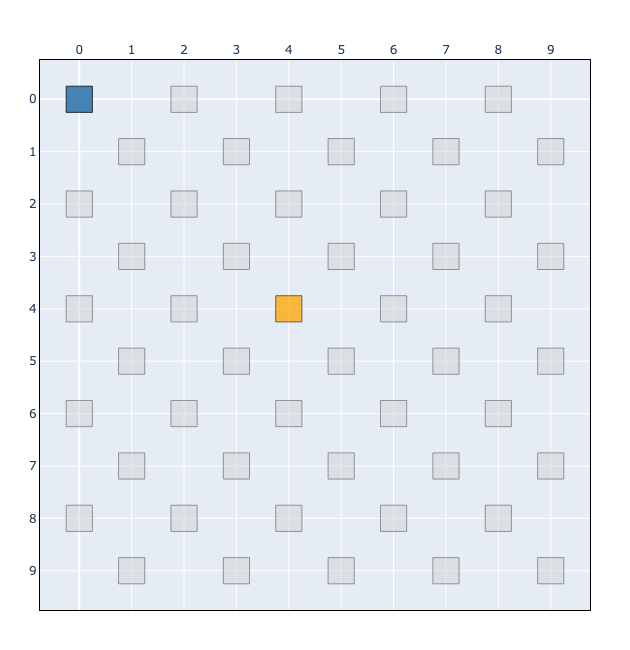

In [4]:
# A qubit's status records whether the site participates in a logical patch.
chip.loc((0, 0)).status = Status.LOGICAL
chip.loc((4, 4)).status = Status.ANCILLA
chip.show(style=default_style)

## 3. Noise models

Real superconducting processors are heterogeneous: physical error rates vary
substantially across the lattice and are frequently correlated in space. Modeling this
heterogeneity faithfully is precisely why qSNOW represents noise as a per-qubit field
rather than a single global parameter.

Every qubit carries a `NoiseProfile` exposing a physical error rate `p` (a bounded float
on `[0, 0.75]`). `Chip` provides a family of *samplers* that populate `p` across the
lattice, each recording its parameters in the chip's metadata for provenance:

- **`generate_uniform_noise(p)`** — a homogeneous field; every qubit shares a single `p`.
- **`generate_random_noise(range)`** — independent draws from a uniform distribution
  over `range`.
- **`generate_gaussian_noise(mean, deviation)`** — independent draws from a truncated
  Gaussian.
- **`generate_derived_contour_noise(mean, deviation, slope=...)`** — a *spatially
  correlated* gradient, in which each site's error rate is derived from a smoothed
  neighborhood average, producing the contoured, non-i.i.d. structure characteristic of
  real devices.

Each sampler also populates the chip's **couplers**, deriving each edge's rate from the
two qubits it joins (section 6); each accepts a `seed` for reproducibility. Below we visualize the
three non-trivial fields with `noise_heatmap_style`, moving from fully independent
(Gaussian, random) to spatially correlated (contour).


noise model : {'name': 'gaussian', 'mean': 0.01, 'deviation': 0.003, 'seed': 42}
p at (2, 2) : 0.01278


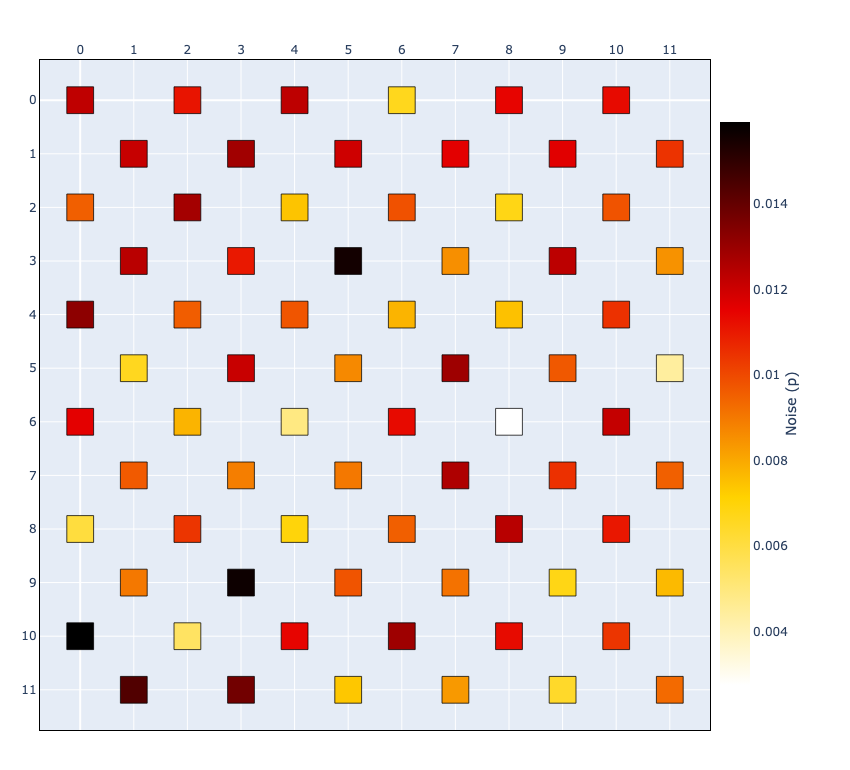

In [5]:
# (a) Truncated-Gaussian field: i.i.d. draws about a target mean.
chip = Chip(6, 6)
chip.generate_gaussian_noise(mean=0.010, deviation=0.003, seed=42)

print("noise model :", chip.summary()["noise_model"])
print("p at (2, 2) :", chip.loc((2, 2)).noise.p)
chip.show(style=noise_heatmap_style(chip))

noise model : {'name': 'uniform random', 'range': (0.005, 0.02), 'seed': 11}


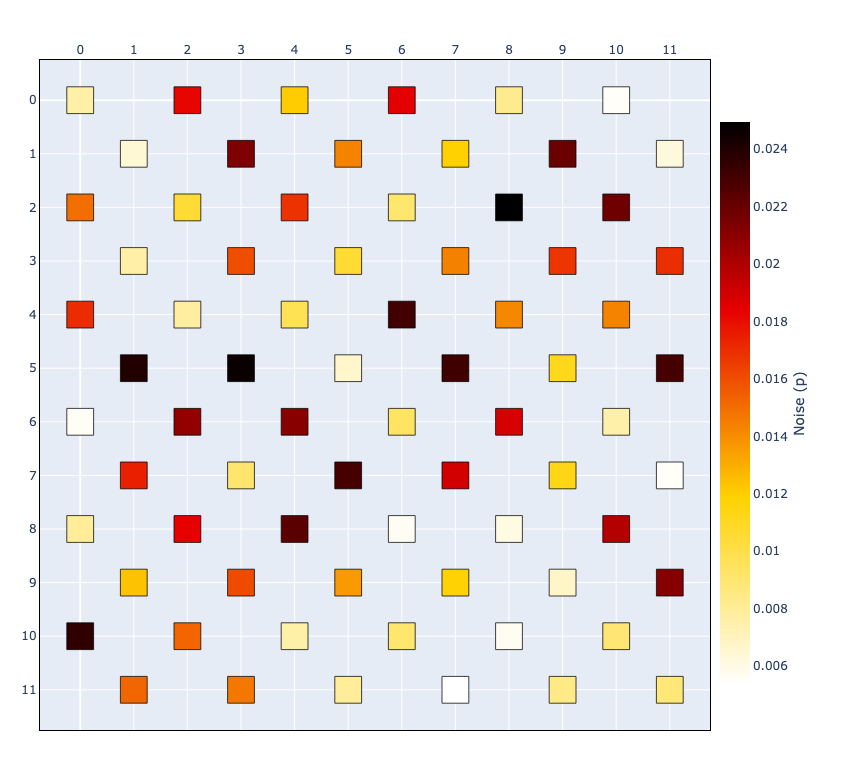

In [6]:
# (b) Uniform-random field over an explicit interval.
chip_rand = Chip(6, 6)
chip_rand.generate_random_noise(range=(0.005, 0.020), seed=11)
print("noise model :", chip_rand.summary()["noise_model"])
chip_rand.show(style=noise_heatmap_style(chip_rand))

### Spatially correlated noise

The samplers above draw each qubit independently, which is convenient but unphysical:
real fabrication variation is *correlated* in space. `generate_derived_contour_noise`
constructs such a field — neighboring qubits take on similar error rates, yielding smooth
gradients and hot spots. The `slope` parameter controls the spatial scale of the
correlation. On a larger chip the contour structure is readily apparent in the heatmap.


noise model : {'name': 'derived contour', 'mean': 0.005, 'deviation': 0.002, 'slope': 5, 'seed': 12}


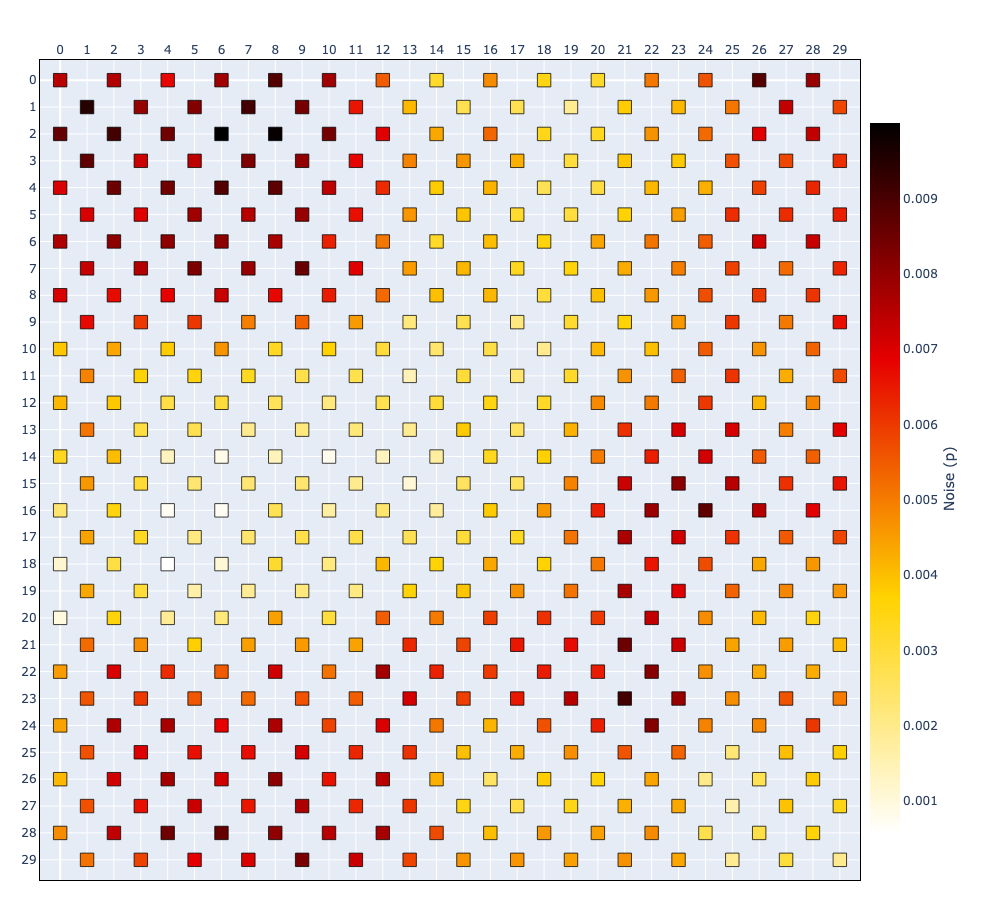

NoiseProfile(p=0.0005599892778335716)


In [7]:
chip_contour = Chip(15, 15)
chip_contour.generate_derived_contour_noise(mean=0.005, deviation=0.002, seed=12, slope=5)
print("noise model :", chip_contour.summary()["noise_model"])
chip_contour.show(style=noise_heatmap_style(chip_contour))
print(min(chip_contour.noise_map.values()))


## 4. Logical tiles — placing a surface code

A **`LogicalTile`** wraps a Stim circuit anchored to a coordinate frame. The
code-specific subclass **`SCTile`** generates a *rotated surface code* of a given
`distance` and assigns each qubit a **CSS type** (`DATA`, `X_CHECK`, `Z_CHECK`,
`BUFFER`).

A tile is placed with `chip.add_tile(tile, loc)`, where `loc` is the tile's origin (its
upper-left qubit). Placement is validated against the checkerboard invariant, the chip
bounds, and overlap with existing tiles. Here we color qubits by CSS type via
`css_style`.


tile summary: {'type': 'RSC', 'dims': (4, 4), 'distance': 3}


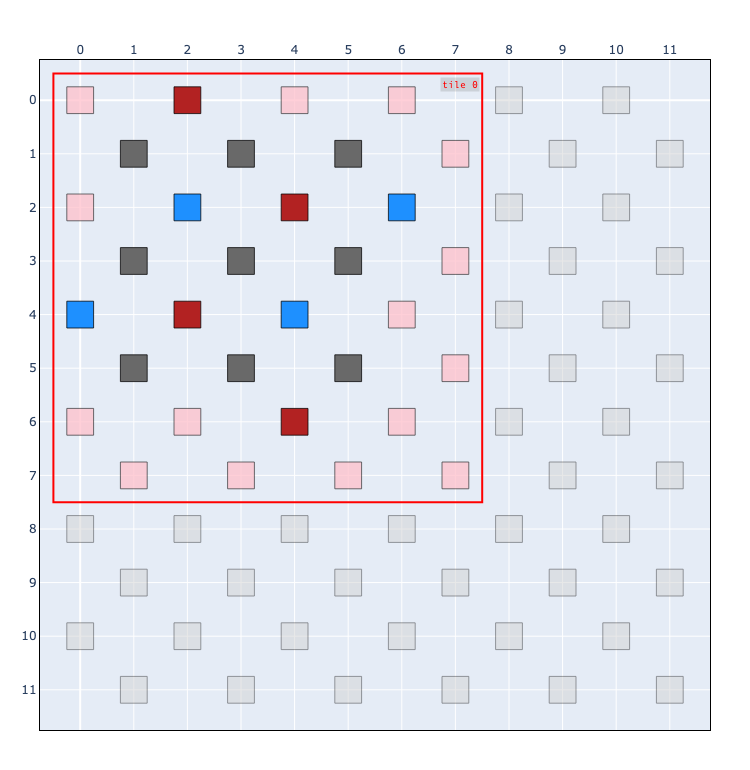

In [8]:
chip = Chip(6, 6)
tile = SCTile(distance=3, rounds=3, task="memory_z")
chip.add_tile(tile)          # no loc -> placed at the tile's own origin (0, 0)

print("tile summary:", tile.summary())
chip.show(style=css_style)

### Relocating tiles

A placed tile may be translated with `shift_to(origin)` or `shift_by(dx, dy)`. A shift
rewrites the `QUBIT_COORDS` within the circuit and transfers qubit statuses, keeping the
physical and logical layers consistent. Every shift must preserve the checkerboard
invariant (`dx % 2 == dy % 2`).


tile origin is now: (2.0, 2.0)


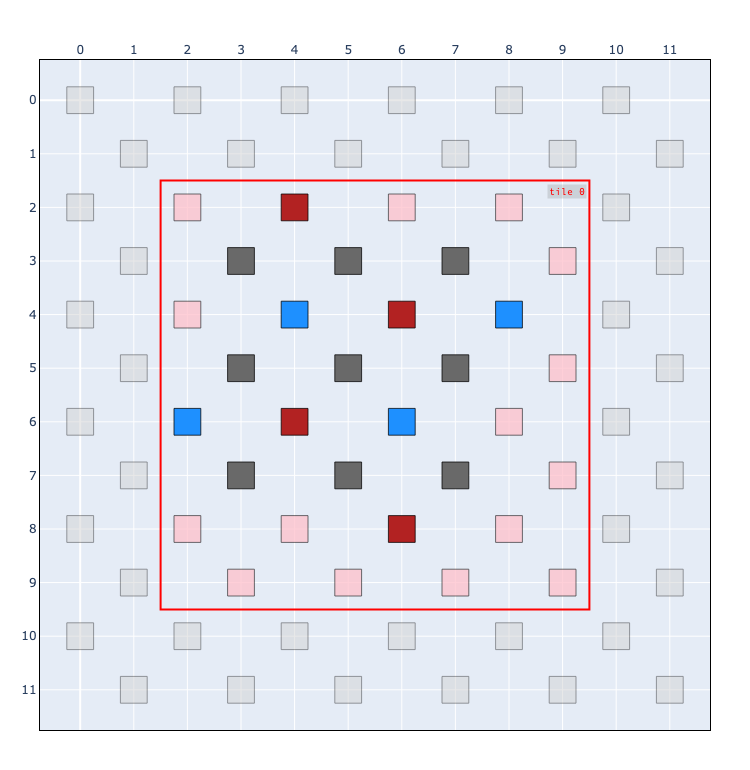

In [9]:
chip.tiles[0].shift_to((2, 2))
print("tile origin is now:", chip.tiles[0].origin)
chip.show(style=css_style)

## 5. Noise injection — coupling the physical and logical layers

This is the heart of qSNOW. A tile holds a **`Ruleset`**: an ordered (priority) list of
`InjectionRule`s. Each rule fires on a named Stim operation (e.g. `CX`, `MR`, `R`) when
its **trigger** — a predicate over the operation's target qubits — passes, and applies
noise **channels** (e.g. `DEPOLARIZE2`, `X_ERROR`) to the qubits selected by a named
**filter**, *before* and/or *after* the operation.

`SCTile` supplies a representative default ruleset:


In [10]:
print(tile._ruleset)

0:InjectionRule(gate=R, on_qubits=all_qubits, before = [], after = [ChannelRule(name=Init,channel=X_ERROR, on_qubits=all_qubits, rate=2.0p, from=qubit_mean)])
1:InjectionRule(gate=H, on_qubits=x_measures, before = [], after = [ChannelRule(name=Clifford1,channel=DEPOLARIZE1, on_qubits=active, rate=0.1p, from=qubit_mean),ChannelRule(name=Idle,channel=DEPOLARIZE1, on_qubits=idle, rate=0.1p, from=qubit_mean)])
2:InjectionRule(gate=CX, on_qubits=any, before = [], after = [ChannelRule(name=Clifford2,channel=DEPOLARIZE2, on_qubits=active, rate=1p, from=coupler),ChannelRule(name=Idle,channel=DEPOLARIZE1, on_qubits=idle, rate=0.1p, from=qubit_mean)])
3:InjectionRule(gate=MR, on_qubits=all_measures, before = [ChannelRule(name=Measure,channel=X_ERROR, on_qubits=all_measures, rate=5.0p, from=qubit_mean), ChannelRule(name=ResonatorIdle,channel=DEPOLARIZE1, on_qubits=idle, rate=2.0p, from=qubit_mean), ChannelRule(name=Idle,channel=DEPOLARIZE1, on_qubits=idle, rate=0.1p, from=qubit_mean)], after = [C

Accessing **`tile.circuit`** walks the base circuit and re-injects noise channels
using each qubit's `noise.p` drawn from the chip. Because injection reads the chip's live
noise map, altering the noise or relocating the tile alters the emitted circuit — nothing
is baked in. For diagnostics, each injected channel can additionally be **tagged** with
the rule that produced it; Stim tags are inert annotations, useful for downstream
tooling.

We assign a sub-threshold noise level and inspect the injected circuit.


In [11]:
chip.generate_gaussian_noise(mean=0.005, deviation=0.0006, seed=7)

noisy_circuit = tile.circuit          # re-injected on every access
print(type(noisy_circuit).__name__,
      f"| {noisy_circuit.num_qubits} qubits, {noisy_circuit.num_ticks} ticks\n")

# The injected channels' probabilities are the mean physical error rate of the qubits
# each channel acts on, drawn live from the chip's noise map.
noise_ops = ("DEPOLARIZE", "X_ERROR", "Y_ERROR", "Z_ERROR")
injected = [ln for ln in str(noisy_circuit).splitlines()
            if ln.lstrip().startswith(noise_ops)]
print(f"{len(injected)} injected noise instructions. First few:\n")
print("\n".join(injected[:6]))

# With provenance tags, each channel names the exact rule (operation:trigger ->
# channel:filter) that produced it:
tagged = tile._inject_circuit_noise(debug_tags=True)
tagged_lines = [ln for ln in str(tagged).splitlines()
                if ln.lstrip().startswith(noise_ops)]
print("\nWith provenance tags:\n")
print("\n".join(tagged_lines[:6]))

Circuit | 26 qubits, 21 ticks

302 injected noise instructions. First few:

X_ERROR(0.01274) 1
X_ERROR(0.01004) 2
X_ERROR(0.00918) 3
X_ERROR(0.01122) 5
X_ERROR(0.00906) 8
X_ERROR(0.0099) 9

With provenance tags:

X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.01274) 1
X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.01004) 2
X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00918) 3
X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.01122) 5
X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00906) 8
X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.0099) 9


Because the result is a genuine Stim circuit, the entire Stim ecosystem applies
directly — for instance, compiling a detector-error model for a decoder:


In [12]:
dem = noisy_circuit.detector_error_model(decompose_errors=True)
print("Detectors        :", noisy_circuit.num_detectors)
print("DEM error terms  :", dem.num_errors)

Detectors        : 24
DEM error terms  : 286


## 6. Couplers — edge-owned two-qubit error rates

Sections 3 and 5 treated the error rate as a property of a **qubit**. That is only half of
a real device. A two-qubit gate's fidelity is dominated by the **coupler** joining the
pair — a distinct fabricated element with its own defects, and *not* a function of the two
qubits it connects. Modelling it as one discards precisely the structure a chip-wide
packing study is trying to find.

qSNOW represents it explicitly. Adjacency is a property of the `Lattice`, which already
owns the site rule; `neighbor_offsets` is derived from the lattice pitch rather than
tabulated, so each lattice gets the correct connectivity for free:

| Lattice | Sites | Coupled neighbours |
|---|---|---|
| `CHECKERBOARD` (pitch 2) | `x % 2 == y % 2` | the four diagonals `(±1, ±1)` |
| `SQUARE` (pitch 1) | every integer coordinate | the four cardinals `(±1, 0), (0, ±1)` |

A `Chip` builds one `Coupler` per adjacent pair, each owning a `NoiseProfile` exactly as a
`Qubit` does. Couplers belong to the *physical* layer: a `LogicalTile` never owns one, and
relocating a patch never carries one along — the same convention that keeps `noise`
attached to a site rather than to a logical role.

Additionally, since to account for differences in qubit architectures (i.e., superconducting
vs. trapped ion), the `Coupler` can be functionally ignored, as the two-qubit interactions
can default to being related solely to the `NoiseProfile` of the two qubits involved in the
operation. For example, instead of having a coupler with a unique `NoiseProfile`, the two-qubit
qubit operations can be set as the mean of the `NoiseProfile` of q1 and q2.

In [13]:
chip = Chip(5, 5)
chip.generate_gaussian_noise(mean=0.005, deviation=0.0006, seed=7)

print(f"lattice          : {chip.lattice.name}, pitch {chip.lattice.pitch}")
print(f"coupled offsets  : {chip.lattice.neighbor_offsets}")
print(f"qubits, couplers : {len(chip.qubits)}, {len(chip.couplers)}"
      f"  (ratio {len(chip.couplers) / len(chip.qubits):.2f})\n")

# A coupler is addressed by its two endpoints, in either order.
c = chip.coupler((0, 0), (1, 1))
print(c)
print("order-independent:", chip.coupler((1, 1), (0, 0)) is c)

# Asking for a pair the lattice does not couple is an error, not a silent zero.
try:
    chip.coupler((0, 0), (2, 2))
except KeyError as e:
    print("\nunlinked pair    :", e)

lattice          : checkerboard, pitch 2
coupled offsets  : ((-1, -1), (-1, 1), (1, -1), (1, 1))
qubits, couplers : 50, 81  (ratio 1.62)

Coupler(ends=(0, 0)<->(1, 1), noise=NoiseProfile(p=0.00544))
order-independent: True

unlinked pair    : "No coupler between (0, 0) and (2, 2). On the 'checkerboard' lattice a coupler joins sites one of ((-1, -1), (-1, 1), (1, -1), (1, 1)) apart."


### Where a coupler's rate comes from

Absent measured per-coupler data, the endpoints are the best available estimate, so every
whole-chip sampler in section 3 also populates the couplers via
**`derive_coupler_noise(mode="mean")`**. This is what makes the feature a no-op until you
actually use it: a derived coupler carries exactly the mean the injector used before
couplers existed.

Because that default is a *derivation*, the chip can tell you whether its couplers carry
any information of their own — `has_independent_couplers`. It is computed on demand rather
than recorded, since both `set_coupler_noise_map()` and a direct write to `coupler.noise.p`
would bypass any bookkeeping a setter could do.

In [14]:
from statistics import mean

# Fresh from a sampler, each coupler is exactly the mean of the two qubits it joins.
derived_ok = all(
    c.noise.p == mean([chip.loc(e).noise.p for e in c.ends]) for c in chip.couplers
)
print(f"every coupler == endpoint mean : {derived_ok}")
print(f"has_independent_couplers       : {chip.has_independent_couplers}\n")

# Give one coupler a defect of its own; the chip now knows it carries independent data.
chip.coupler((0, 0), (1, 1)).noise.p = 0.05
print(f"after overriding one coupler   : {chip.has_independent_couplers}")

# `derive_coupler_noise` re-derives wholesale; "max" models a worst-endpoint device.
chip.derive_coupler_noise("max")
print(f"after re-deriving (mode='max') : {chip.has_independent_couplers}")

every coupler == endpoint mean : True
has_independent_couplers       : False

after overriding one coupler   : True
after re-deriving (mode='max') : False


### The rule engine's third axis

Section 5 described a `ChannelRule` as answering *which* qubits get a channel (its
**filter**), fired when a rule's **trigger** passes. A channel can also declare **where
its rate is read from**, it's **source**, resolved through a name registry identical in
shape to the trigger and filter registries:

| Axis | Question | Registry |
|---|---|---|
| `trigger` | *when* does this rule fire? | `any`, `all_measures`, `data`, … |
| `filter` | *which* qubits receive the channel? | `active`, `idle`, `data`, … |
| **`source`** | ***where* does the rate come from?** | **`qubit_mean`, `qubit_max`, `coupler`** |

`qubit_mean` is the default and reproduces the historical behaviour. `SCTile`'s SI1000
ruleset points its one two-qubit rule at the coupler instead:

```python
apply_channel("DEPOLARIZE2", "active", 1, name="Clifford2", source="coupler")
```

Custom sources register at runtime through `ruleset.add_source(Source(name, fn))`, so a
device with, say, a crosstalk-dependent rate needs no change to the injector.

In [15]:
chip = Chip(5, 5)
chip.generate_uniform_noise(0.005)          # couplers derive to 0.005 as well
tile = SCTile(distance=3)
chip.add_tile(tile, (0, 0))

cx_rule = next(r for r in tile.ruleset.rules if r.operation == "CX")
print(cx_rule, "\n")

def depolarize2_args(t):
    return [i.gate_args_copy()[0] for i in t.circuit.flattened() if i.name == "DEPOLARIZE2"]

print(f"DEPOLARIZE2 rates, derived couplers : {sorted(set(depolarize2_args(tile)))}")

# Introduce a single defective coupler on an edge the patch's CX gates actually span.
i2c = tile._circuit.get_final_qubit_coordinates()
cx = next(i for i in tile._circuit.flattened() if i.name == "CX")
a, b = ((i2c[t.value][0], i2c[t.value][1]) for t in cx.target_groups()[0])
chip.coupler(a, b).noise.p = 0.05

print(f"DEPOLARIZE2 rates, one bad coupler  : {sorted(set(depolarize2_args(tile)))}")
print(f"\nthe defective edge {a} <-> {b} raises that one gate alone;"
      f"\nevery other CX still reads the derived 0.005.")

InjectionRule(gate=CX, on_qubits=any, before = [], after = [ChannelRule(name=Clifford2,channel=DEPOLARIZE2, on_qubits=active, rate=1p, from=coupler),ChannelRule(name=Idle,channel=DEPOLARIZE1, on_qubits=idle, rate=0.1p, from=qubit_mean)]) 

DEPOLARIZE2 rates, derived couplers : [0.005]
DEPOLARIZE2 rates, one bad coupler  : [0.005, 0.05]

the defective edge (2.0, 0.0) <-> (3.0, 1.0) raises that one gate alone;
every other CX still reads the derived 0.005.


### Visualizing couplers — conditional by design

Rendering the edge layer is **opt-in, and off by default**, for a reason worth stating
plainly: while couplers sit at their derived value they are a *function of the qubit rates
the same figure already draws*. Plotting them would restate that data as though it were a
second, independent measurement. It is also a great deal of ink — couplers outnumber
qubits 1.62× on a 5×5 chip and approach 2× as the chip grows.

So the layer appears exactly when it carries information. `couplers="auto"` (the default)
resolves through `has_independent_couplers`; `True` and `False` force it either way:

| Call | Derived couplers | Overridden coupler |
|---|---|---|
| `noise_heatmap_style(chip)` | no edges | edges drawn |
| `noise_heatmap_style(chip, couplers=True)` | edges drawn | edges drawn |
| `noise_heatmap_style(chip, couplers=False)` | no edges | no edges |

Qubit and coupler `p` are the same quantity on the same bound, so the enabled layer widens
and shares the single colorbar rather than introducing a competing scale.

In [16]:
def edge_count(c, **kwargs) -> int:
    # Number of coupler line shapes a noise heatmap of `c` would draw.
    fig = visualize(c, style=noise_heatmap_style(c, **kwargs))
    return sum(1 for s in fig.layout.shapes if s.type == "line")

chip = Chip(5, 5)
chip.generate_gaussian_noise(mean=0.005, deviation=0.0006, seed=7)
print(f"derived    | auto  : {edge_count(chip):>3d} edges")
print(f"derived    | True  : {edge_count(chip, couplers=True):>3d} edges")

chip.coupler((0, 0), (1, 1)).noise.p = 0.05
print(f"overridden | auto  : {edge_count(chip):>3d} edges")
print(f"overridden | False : {edge_count(chip, couplers=False):>3d} edges")

derived    | auto  :   0 edges
derived    | True  :  81 edges
overridden | auto  :  81 edges
overridden | False :   0 edges


`coupler_heatmap_style` makes the edges the subject rather than the context, greying the
qubits behind them. Below, the single defective coupler introduced above stands out
against a lattice whose edges are otherwise all near the 0.005 mean — the failure mode
that a purely per-qubit view cannot express at all.

The same conditionality governs the interactive bundle: `chip.show(interactive=True)`
gains its coupler entries — **“Coupler Noise”** here, and **“Qubit + Coupler”** introduced
below — only when the couplers are independent, so the dropdown never offers a view that
merely restates another.

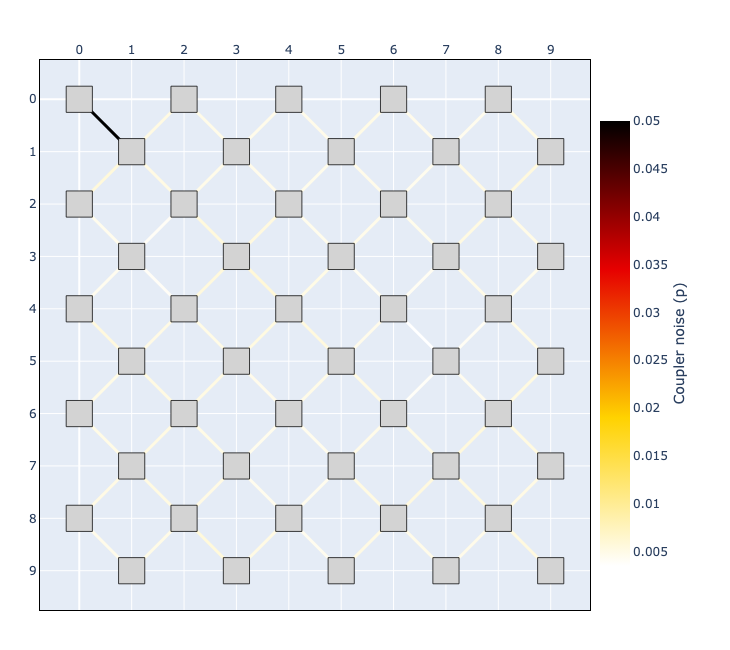

In [17]:
chip.show(style=coupler_heatmap_style(chip))

In [18]:
# The interactive bundle picks up the extra view automatically.
print("views, independent couplers:", list(default_interactive_styles(chip)))
print("views, derived couplers    :", list(default_interactive_styles(Chip(5, 5))))

views, independent couplers: ['Status', 'CSS Type', 'Noise', 'Coupler Noise', 'Qubit + Coupler']
views, derived couplers    : ['Status', 'CSS Type', 'Noise']


### Both layers at once — `device_heatmap_style`

The views so far give the two layers **one shared colour scale**, which is correct while
the couplers are derived: they are means of their endpoints, so both occupy the same range
by construction. It stops being correct as soon as the couplers carry measured rates.
Two-qubit gates are typically several times worse than single-qubit ones, and forcing both
onto one scale compresses every qubit into the bottom of the bar.

`device_heatmap_style` gives each layer **its own independently scaled colorbar**. It is
otherwise the same picture as `noise_heatmap_style`. The coupler and qubit colorbars, by default,
still run light-to-dark, so "darker is worse" reads the same on either layer.

qubits   :  120   Qubit (p)    0.001462 - 0.009818
couplers :  218   Coupler (p)  0.003345 - 0.06092

independent scales keep both layers legible; one shared scale would flatten
the qubits into the bottom fraction of the coupler range.


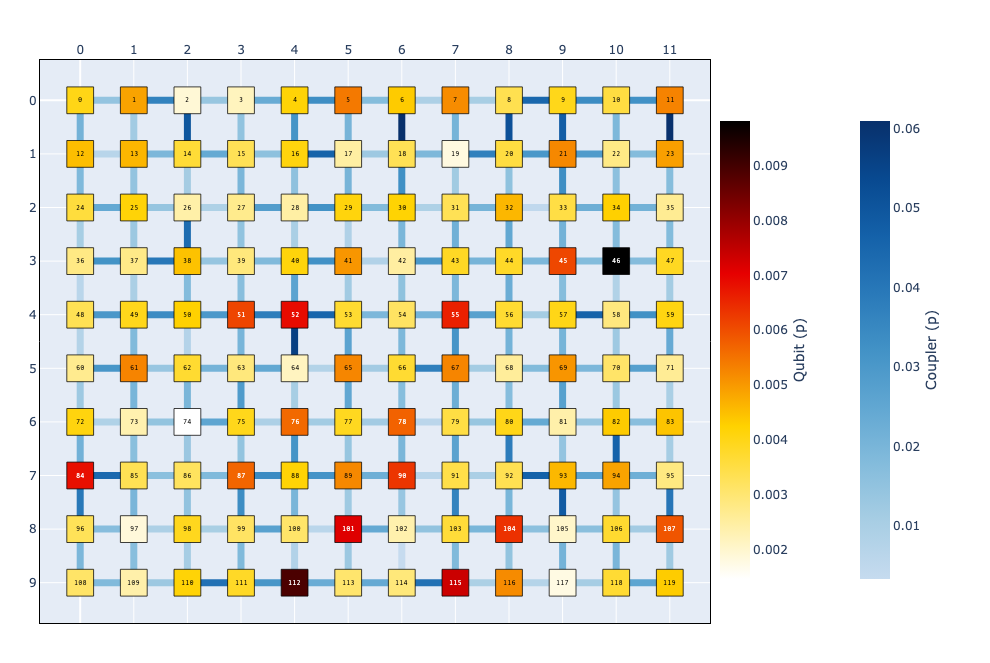

In [19]:
from qsnow.interface.lattice import SQUARE

# A dense-lattice device with independently measured qubit and coupler rates: couplers
# average roughly an order of magnitude worse, as they do on real hardware.
rng = np.random.default_rng(7)
device = Chip(12, 10, lattice=SQUARE)
for q in device.qubits:
    q.noise.p = float(np.clip(rng.lognormal(np.log(0.004), 0.40), 1e-6, 0.7))
for cp in device.couplers:
    cp.noise.p = float(np.clip(rng.lognormal(np.log(0.020), 0.55), 1e-6, 0.7))

style = device_heatmap_style(device, labels=True)
print(f"qubits   : {len(device.qubits):>4d}   {style.colorbar.label:<12s}"
      f" {style.colorbar.cmin:.4g} - {style.colorbar.cmax:.4g}")
print(f"couplers : {len(device.couplers):>4d}   {style.coupler_colorbar.label:<12s}"
      f" {style.coupler_colorbar.cmin:.4g} - {style.coupler_colorbar.cmax:.4g}")
print("\nindependent scales keep both layers legible; one shared scale would flatten"
      "\nthe qubits into the bottom fraction of the coupler range.")

device.show(style)

`labels=True` numbers the qubits in reading order, for cross-referencing a device data
file. The label colour is chosen per marker from its own fill: `hot_r` is white at the low
end and black at the high end, so a fixed colour would disappear at one extreme.

The alternate **`preset="device"`** look is one argument away — circular qubits, the
perceptually uniform `Viridis_r`/`Magma_r` ramps, log-scaled rates and top-mounted bar
titles. It is denser and better suited to a standalone device site map; the default suits a
figure sitting beside the rest of qSNOW's views. A preset flips every one of those choices
together, so neither look can be half-applied.

As shown previously, the visualization includes an interactive mode that allows for quickly 
switching through contextually relevant visuals. Additional non-default styles can be added 
using the `extra_styles` arguement, like adding the `preset="device"` heatmap style below.

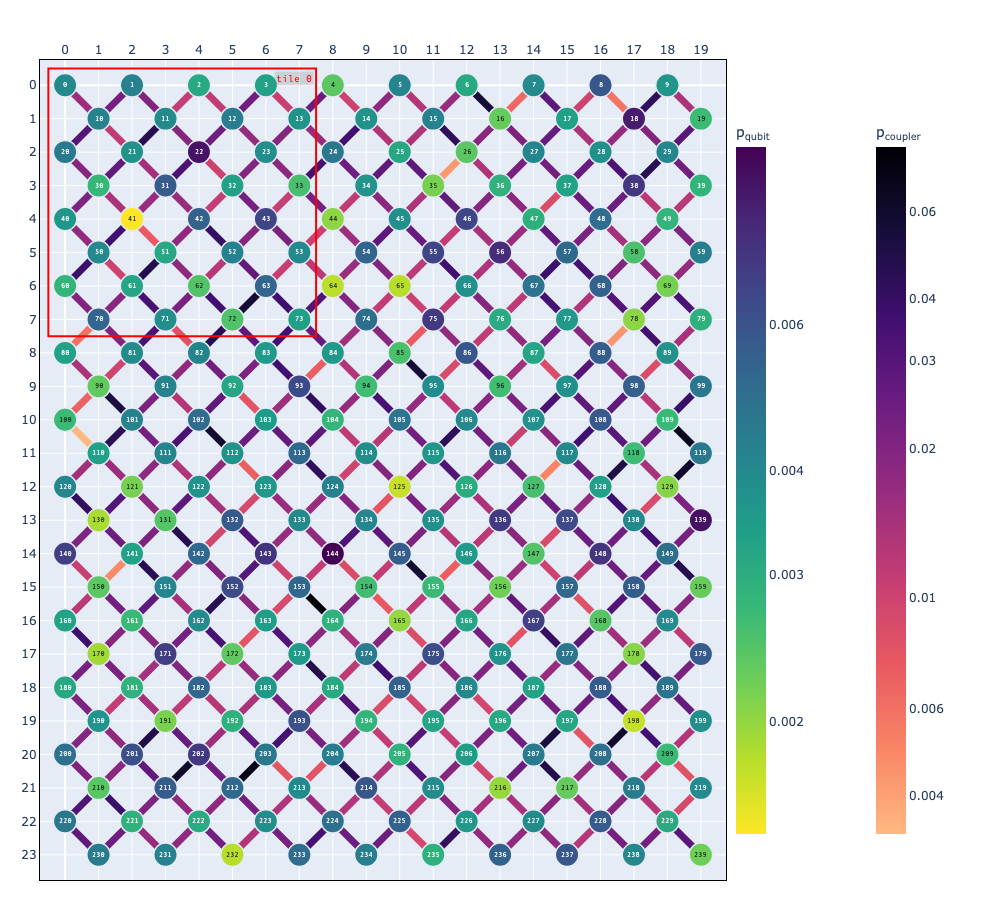

In [34]:
from qsnow.interface.lattice import CHECKERBOARD

# A checkerboard-lattice device with independently measured qubit and coupler rates: couplers
# average roughly an order of magnitude worse, as they (approximately) do on real hardware.
rng = np.random.default_rng(7)
device = Chip(10, 12, lattice=CHECKERBOARD)
for q in device.qubits:
    q.noise.p = float(np.clip(rng.lognormal(np.log(0.004), 0.40), 1e-6, 0.7))
for cp in device.couplers:
    cp.noise.p = float(np.clip(rng.lognormal(np.log(0.020), 0.55), 1e-6, 0.7))

device.add_tile(SCTile(3), (0,0))

style = device_heatmap_style(device, preset='device', labels=True)

device.show(style=style)

# If showing additional interactive mode...
# device.show(interactive=True, extra_styles={'Device': device_heatmap_style(device, preset="device", labels=True)})

Either preset accepts `log=` to override its default scale, and `qubit_colorscale=` /
`coupler_colorscale=` for a bespoke pairing:

In [21]:
for preset in ("qsnow", "device"):
    s = device_heatmap_style(device, preset=preset)
    marker = s.style_fn(device.qubits[0])
    print(f"{preset:8s} marker={marker.marker!r} size={marker.size}"
          f"  titles={s.colorbar.title_side:<5s}"
          f"  log={s.colorbar.ticktext is not None}")

# ...and the house preset is deliberately indistinguishable from `noise_heatmap_style`
# wherever the two make the same choice:
house = noise_heatmap_style(device).style_fn(device.qubits[0])
device_q = device_heatmap_style(device).style_fn(device.qubits[0])
print("\nmatches noise_heatmap_style on marker/size/edge:",
      (house.marker, house.size, house.edgecolor, house.linewidths)
      == (device_q.marker, device_q.size, device_q.edgecolor, device_q.linewidths))

qsnow    marker='s' size=0.5  titles=right  log=False
device   marker='o' size=0.7  titles=top    log=True

matches noise_heatmap_style on marker/size/edge: True


Because the couplers here carry rates of their own, `chip.show(interactive=True)` offers
**five** views rather than three — the three standard ones, plus `Coupler Noise` (edges as
the subject) and `Qubit + Coupler` (this combined view).

In [22]:
print("views:", list(default_interactive_styles(device)))

views: ['Status', 'CSS Type', 'Noise', 'Coupler Noise', 'Qubit + Coupler']


## 7. Packing heterogeneous logical patches

A chip is a workspace for *many* tiles, and `add_tile` rejects overlapping or
out-of-bounds placements. Patches of **different code distances** may therefore be tiled
together over a shared, non-uniform noise field — the setting in which packing questions
become interesting. Use `tile.copy()` (or a fresh constructor) to stamp independent,
uninitialized patches.

The layout below combines a row of three `d=3` patches with a `d=5` and a `d=7` patch,
first colored by CSS type, then overlaid on the underlying noise.


Placed 5 patches: distances [3, 3, 3, 5, 7]


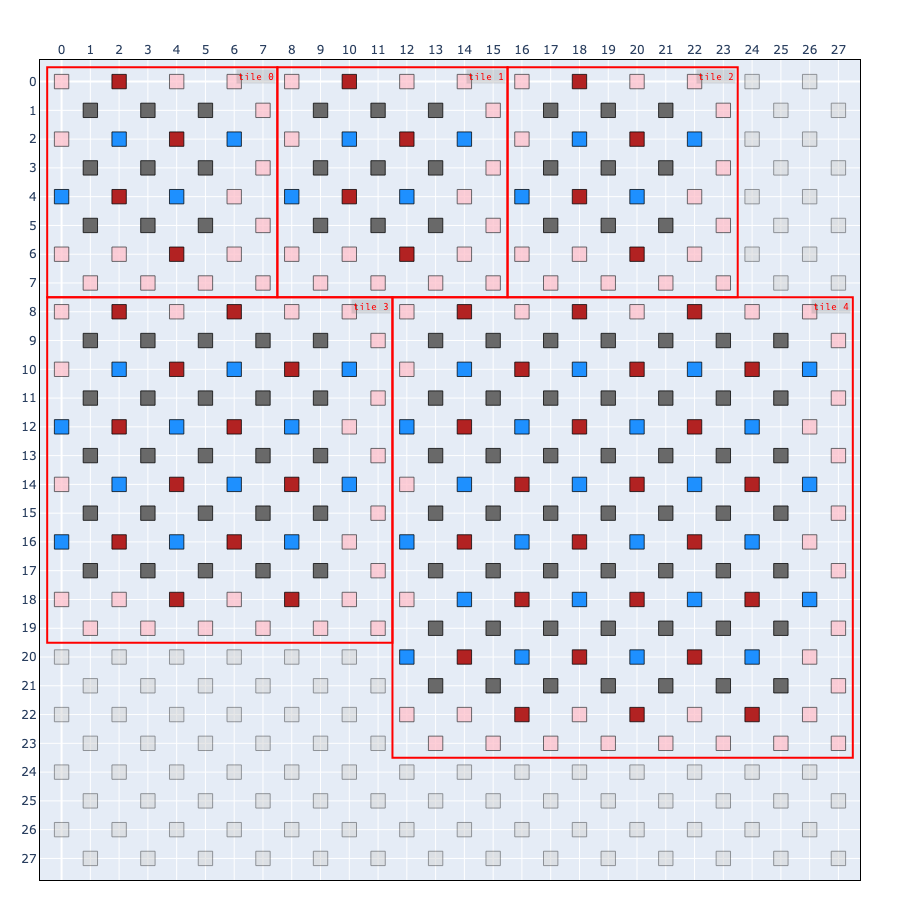

In [23]:
chip = Chip(14, 14)
chip.generate_gaussian_noise(mean=0.012, deviation=0.004, seed=3)

placements = [
    (SCTile(distance=3), (0, 0)),
    (SCTile(distance=3), (8, 0)),
    (SCTile(distance=3), (16, 0)),
    (SCTile(distance=5), (0, 8)),
    (SCTile(distance=7), (12, 8)),
]
for patch, loc in placements:
    chip.add_tile(patch, loc)

print(f"Placed {len(chip.tiles)} patches: "
      f"distances {sorted(t.spec.distance for t in chip.tiles)}")
chip.show(style=css_style)

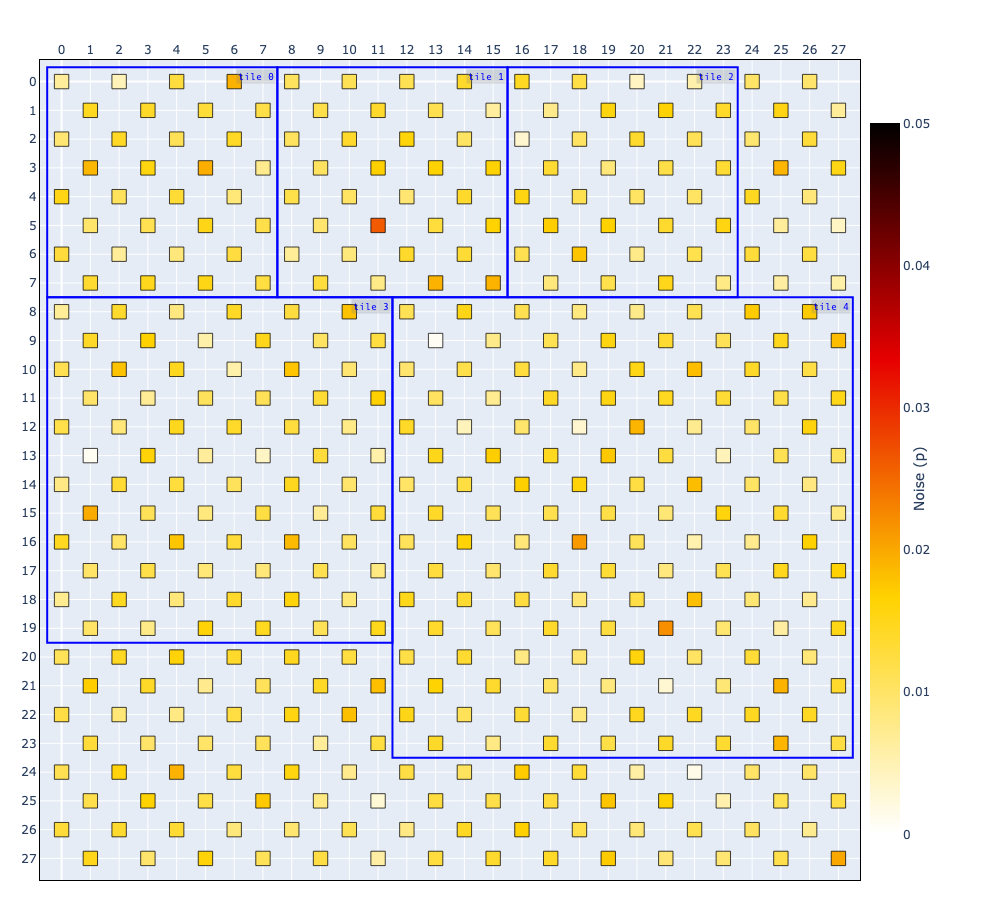

In [24]:
# The same heterogeneous layout, overlaid on the physical error rate:
chip.show(style=noise_heatmap_style(chip, limits=(0.0, 0.05)))

## 8. An experiment: `SquarePackingExp`

Experiments are abstractions built *with* the toolbox to answer a specific question.
`SquarePackingExp` sweeps a tile across **every valid placement** on a chip, constructs
the noise-injected circuit at each candidate site, and estimates the **logical error rate
(LER)** with [`sinter`](https://github.com/quantumlib/Stim). Rather than treating each
qubit as either nominal or unusable, the sweep asks where a patch can *tolerate* the
surrounding heterogeneity: the result exposes which regions of a noisy chip can host a
logical qubit within its target performance — i.e., below the BAD threshold.

The run below is deliberately small (few placements, few shots) so that it completes
quickly; production runs use far larger shot counts.


In [25]:
exp_chip = Chip(7, 7)
exp_chip.generate_gaussian_noise(mean=0.006, deviation=0.0015, seed=3)

exp = SquarePackingExp(exp_chip, SCTile(distance=3))
print("Candidate placements to sample:", len(exp.profile))

Candidate placements to sample: 25


In [26]:
results = exp.run(shots=1_000, max_errors=200, max_workers=4)

# results maps each placement origin -> its sampled logical error rate
for loc, stat in list(results.items())[:5]:
    print(f"  origin {loc}: LER = {stat['ler']:.4f}  ({stat['errors']}/{stat['shots']})")
print(f"  ... {len(results)} placements total")

Experiment: SquarePackingExp


[1/3] Generating circuits:   0%|          | 0/25 [00:00<?, ?it/s]

[2/3] Sampling circuits:   0%|          | 0/25 [00:00<?, ?it/s]

  origin (0, 2): LER = 0.1050  (105/1000)
  origin (0, 0): LER = 0.1280  (128/1000)
  origin (0, 6): LER = 0.1230  (123/1000)
  origin (0, 4): LER = 0.1340  (134/1000)
  origin (1, 1): LER = 0.1070  (107/1000)
  ... 25 placements total


`exp.show(...)` renders the run as an interactive figure with a dropdown across the
per-qubit error rate (PER), the candidate placement sites, the mean PER under each
footprint, and the sampled LER.


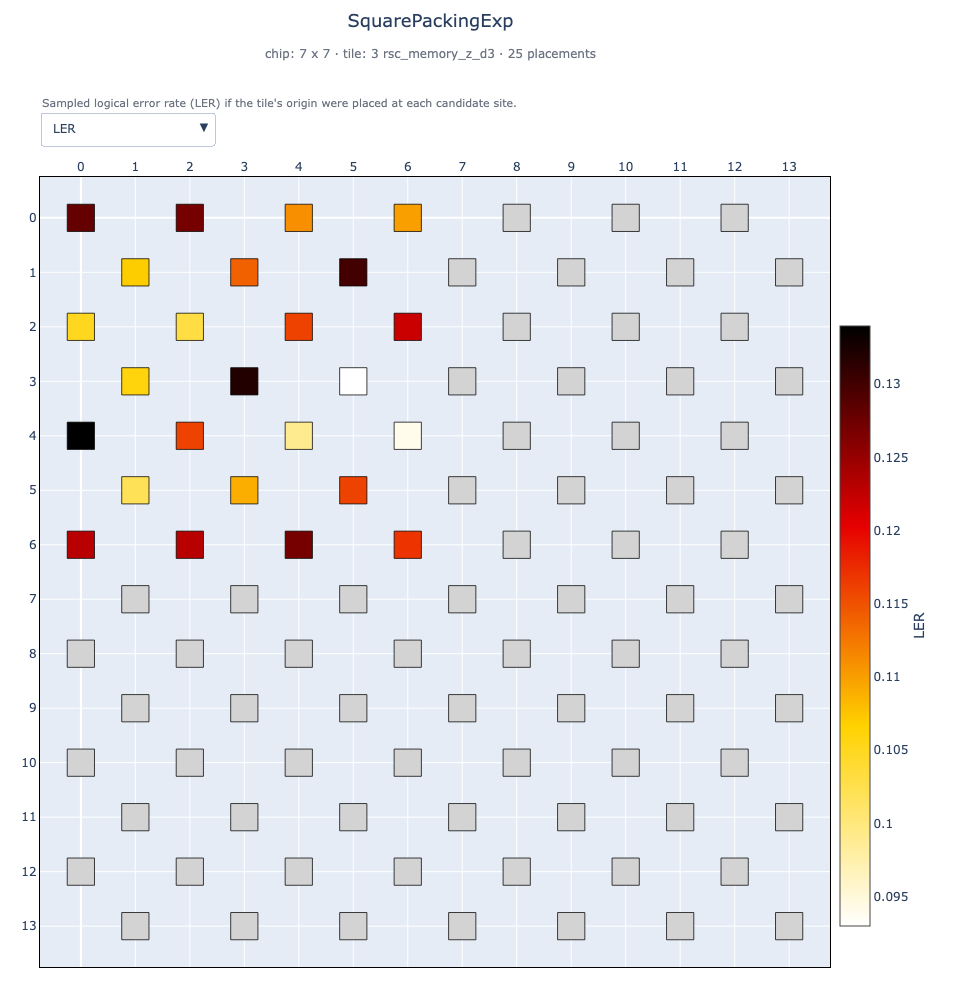

In [27]:
run = ExperimentResults(
    experiment_ref=None,
    run_config=exp.config,
    results=exp.results,
)
exp.show(run)

## 9. Serialization — qSNOW *flakes*

Every qSNOW object supports export as a **`.flake`** file: a serialized qSNOW
configuration capturing everything required to reconstruct the object. The serialization
library thus supports **round-tripping** (1:1 import/export) of `Chip`, `LogicalTile`
(and code subclasses such as `SCTile`), and `Experiment` (currently `SquarePackingExp`)
through `.flake` JSON. Any object is serialized with `serialize.export_flake(obj)`, which
writes to a location determined by the global data directory and an object-specific
naming scheme:

```python
export_flake(chip)                    # -> data/chips/chip_<L>x<H>_<timestamp>.flake
export_flake(tile)                    # -> data/tiles/tile_rsc_memory_z_d3_<timestamp>.flake
export_flake(experiment, label='e1')  # -> data/experiments/experiment_e1_<timestamp>.flake
chip = import_latest("chip")          # newest export matching the pattern
chip = import_flake("data/chips/chip_5x5_2026-07-10_12-00-00.flake")
export_flake(chip, "somewhere/else.flake")   # an explicit path is honored, bypassing the naming scheme
```

A few semantics are worth stating explicitly:

- **Chips do not store qubit statuses or CSS types.** They are re-derived on import by
  re-placing each tile through `add_tile`, so the reconstruction is faithful without
  duplicating derived state.
- **Custom triggers/filters cannot be serialized.** They hold live callables; a warning
  is emitted on export, and only the default (named) rules survive the round trip.
- **New tile subclasses** must be registered via `register_tile_type()` to be importable.


In [28]:
# Export the chip, a fresh tile, and the experiment. Each lands in its own subfolder.
chip_path = serialize.export_flake(chip, label="getting_started_chip")
tile_path = serialize.export_flake(SCTile(distance=3), label="rsc_d3")
exp_path  = serialize.export_flake(exp, label="getting_started_sp")

data_dir = serialize.get_data_dir()
for p in (chip_path, tile_path, exp_path):
    print("wrote:", p.relative_to(data_dir))

wrote: chips/chip_getting_started_chip_2026-09-01_15-14-11.flake
wrote: tiles/tile_rsc_d3_2026-09-01_15-14-11.flake
wrote: experiments/experiment_getting_started_sp_2026-09-01_15-14-11.flake


In [29]:
# Reconstruct objects from disk. import_flake takes an explicit path; import_latest
# resolves the newest export matching a glob pattern.
restored_chip = serialize.import_flake(chip_path)
restored_exp = serialize.import_latest("*getting_started_sp*")

print("restored chip:", restored_chip.summary())
print("restored exp :", type(restored_exp).__name__, "->", restored_exp.summary())

Found 22 matching flakes...
Importing flake at /Users/jakepalmer/Code/Projects/qSNOW/data/experiments/experiment_getting_started_sp_2026-09-01_15-14-11.flake
restored chip: {'unit_size': (14, 14), 'grid_size': (28, 28), 'lattice': 'checkerboard', 'n_qubits': 392, 'n_couplers': 729, 'n_tiles': 5, 'noise_model': {'name': 'gaussian', 'mean': 0.012, 'deviation': 0.004, 'seed': 3}, 'independent_couplers': False}
restored exp : SquarePackingExp -> {'chip': {'unit_size': (7, 7), 'grid_size': (14, 14), 'lattice': 'checkerboard', 'n_qubits': 98, 'n_couplers': 169, 'n_tiles': 0, 'noise_model': {'name': 'gaussian', 'mean': 0.006, 'deviation': 0.0015, 'seed': 3}, 'independent_couplers': False}, 'tile': {'type': 'RSC', 'dims': (4, 4), 'distance': 3}, 'placements': 25}


### Relocating the data directory

The default export root is `data/` at the repository root. It can be redirected with
`serialize.set_data_dir(...)`, which is useful for keeping a run's artifacts self-
contained (passing `None` restores the default):

```python
serialize.set_data_dir('/path/to/flakes')
export_flake(tile, label='processor_config_1')   # -> /path/to/flakes/tiles/tile_processor_config_1_<timestamp>.flake
tile = serialize.import_latest('tile*config_1')  # matches the export above
serialize.set_data_dir(None)                     # restore the default
```

### Standalone interactive visuals

`Chip` and `SquarePackingExp` can additionally be exported as self-contained interactive
HTML pages via `visualize.export_html(obj)`, bundling every applicable default style so
the figure remains fully interactive without a running kernel. *(Experiment exports
require the run's results, passed as the `results` keyword.)*


In [30]:
html_path = export_html(chip, label="getting_started_chip")
print("wrote standalone HTML:", html_path.relative_to(serialize.get_data_dir()))

wrote standalone HTML: html/chip_getting_started_chip_2026-09-01_15-14-11.html
